# Numerical Integration and Differentiation

examples

In [1]:
import numpy as np
from fractions import Fraction
from functools import reduce, lru_cache

from scipy import linalg as la
import scipy.optimize as opt
from scipy import special, interpolate, integrate
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
np.set_printoptions(suppress=True, precision=6)  # 抑制科学计数法，小数位6位

def sign(x):
    s = np.sign(x)
    return s if s else 1

In [2]:
def monomial_coef(nodes, b):
    A = np.vander(nodes, increasing=True)
    return la.solve(A, b)


def monomial_bases(nodes):
    return [Polynomial([0] * n + [1]) for n in range(len(nodes))]


def lagrange_bases(nodes):
    nodes = np.array(nodes, dtype=float)
    n = len(nodes)
    lx = [reduce(Polynomial.__mul__, [Polynomial([-a, 1])for a in nodes[np.arange(n) != i]]) for i in range(n)]
    wx = [1 / (nodes[i] - nodes[np.arange(n) != i]).prod() for i in range(n)]
    return [l * w for l, w in zip(lx, wx)]


def newton_bases(nodes):
    nodes = np.array(nodes, dtype=float)
    n = len(nodes)
    return [Polynomial([1])] + [reduce(Polynomial.__mul__, [Polynomial([-a, 1]) for a in nodes[:i+1]]) for i in range(n-1)]


def newton_coef_axb(nodes, b):
    nodes = np.array(nodes, dtype=float)
    ps = newton_bases(nodes)
    A = np.array([p(nodes) for p in ps]).T
    # print(np.linalg.cond(A))
    return la.solve(A, b)


def newton_incr(q, p, x, y):
    return (y - q(x)) / p(x)


def newton_coef_incr(nodes, b):
    ps = newton_bases(nodes)
    qs = [Polynomial([b[0]])]
    xs = [b[0]]
    for i in range(1, len(nodes)):
        xs.append(newton_incr(qs[-1], ps[i], nodes[i], b[i]))
        qs.append(qs[-1] + xs[-1] * ps[i])
    return np.array(xs)


def newton_coef_recur(nodes, b):

    @lru_cache
    def divided_difference(i, j):
        if i == j:
            return b[i]
        else:
            return (divided_difference(i+1, j) - divided_difference(i, j-1)) / (nodes[j] - nodes[i])
        
    return np.array([divided_difference(0, i) for i in range(len(nodes))])


def monomial_horner(coef, x):
    s = np.zeros_like(x) if isinstance(x, np.ndarray) else 0
    for a in coef[::-1][:-1]:
        s = (s + a) * x
    s += coef[0]
    return s


def newton_horner(coef, x, nodes):
    coef, nodes = coef[::-1], nodes[::-1]
    s = np.zeros_like(x) if isinstance(x, np.ndarray) else 0
    for a, t in zip(coef, nodes[1:]):
        s = (s + a) * (x - t)
    s += coef[-1]
    return s

In [3]:
def open_newton_cotes(a, b, n):
    return np.linspace(a, b, n+2)[1:-1]


def closed_newton_cotes(a, b, n):
    return np.linspace(a, b, n)


def midpoint(f, a, b):
    return (b - a) * f((a + b) / 2)


def trapezoid(f, a, b):
    return .5 * (b - a) * (f(a) + f(b))


def simpson(f, a, b):
    return 1 / 6 * (b - a) * (f(a) + 4 * f((a + b) / 2) + f(b))

0.7788007830714049
0.6839397205857212
0.7471804289095104
<class 'numpy.polynomial.polynomial.Polynomial'>


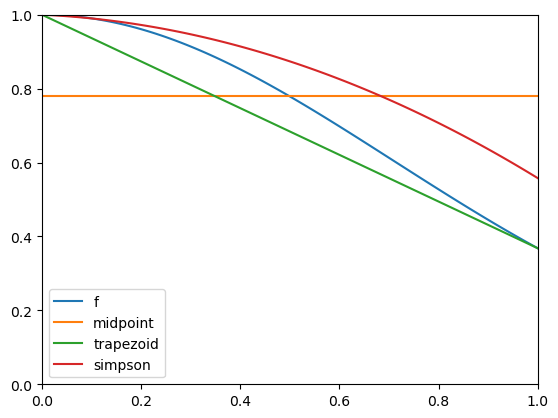

In [4]:
# 8.2
def f(x):
    return np.exp(- x ** 2)

print(midpoint(f, 0, 1))
print(trapezoid(f, 0, 1))
print(simpson(f, 0, 1))

pm = sum(w * p for w, p in zip(monomial_coef([.5], [f(.5)]), monomial_bases([.5])))
print(type(pm))
pt = sum(w * p for w, p in zip([f(0), f(1)], lagrange_bases([0, 1])))
ps = sum(w * p for w, p in zip(newton_coef_incr([0, .5, 1], [f(0), f(.5), f(1)]), newton_bases([0, .5, 1])))

x = np.linspace(0, 1, 101)
plt.plot(x, f(x), label='f')
plt.plot(x, monomial_horner(pm.coef, x), label='midpoint')
plt.plot(x, pt(x), label='trapezoid')
plt.plot(x, newton_horner(ps.coef, x, [0, .5, 1]), label='simpson')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()

In [5]:
# 8.3
im = Fraction(midpoint(np.square, 0, 1))
it = Fraction(trapezoid(np.square, 0, 1))
e = (it - im) / 3
print(im, it, e)

print(im * 2 / 3 + it / 3)
print(simpson(np.square, 0, 1))

1/4 1/2 1/12
1/3
0.3333333333333333


In [6]:
# Chebyshev extrema progressive
n = 10
n_roots = special.chebyu(n).roots

cnt = 0
for x in special.chebyu(2 * n + 1).roots:
    if np.abs(n_roots - x).min() > 1e-8:
        cnt += 1
cnt

11

In [7]:
# 8.4
def f(x):
    return np.array([
        x[0] + x[1] - 2,
        x[0] * x[2] + x[1] * x[3],
        x[0] * x[2] ** 2 + x[1] * x[3] ** 2 - 2 / 3,
        x[0] * x[2] ** 3 + x[1] * x[3] ** 3,
    ])


opt.root(f, [0, 0, 1, 1])

 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00 -9.343e-13 -5.618e-12  1.562e-12]
       x: [ 1.000e+00  1.000e+00  5.774e-01 -5.774e-01]
  method: hybr
    nfev: 45
    fjac: [[-8.404e-01 -4.834e-01 -1.295e-01  2.082e-01]
           [-5.406e-01  7.331e-01  1.619e-01 -3.796e-01]
           [ 3.796e-02 -1.972e-01 -6.656e-01 -7.188e-01]
           [-5.497e-03  4.359e-01 -7.170e-01  5.440e-01]]
       r: [-1.190e+00 -4.970e-01 -4.606e-01 -3.195e-01 -1.077e+00
            6.321e-01  5.133e-01 -1.194e+00  4.052e-01  1.157e+00]
     qtf: [-3.983e-10  5.801e-10 -7.274e-10 -1.185e-09]

In [ ]:
# gauss legendre quadrature
from numpy.polynomial import Legendre

Legendre.basis(2).roots()

array([-0.57735,  0.57735])

In [13]:
# 8.5
def standard_gauss_quad(f, n):
    if n == 2:
        return f(- 1 / np.sqrt(3)) + f(1 / np.sqrt(3))


def gauss_quad(f, a, b, n=2):
    return (b - a) / 2 * standard_gauss_quad(lambda x: f(((b - a) * x + a + b) / 2), n=n)


def f(x):
    return np.exp(- x ** 2)


gauss_quad(f, 0, 1)

np.float64(0.7465946882828598)